In [1]:
import geopy.distance
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sn
import numpy as np
import xarray
import json
from datetime import datetime
from adjustText import adjust_text

Script to calculate Meteor ship track
Forked from https://gitlab.gwdg.de/julia.windmiller/orcestra 
Code by Julia Windmiller, with modifications by Allison Wing

## Monthly mean precipitation from GPCP

In [2]:
precipMonthlyMean = xarray.open_mfdataset('gpcpPrecipMonthlyMean.nc')
precipMonthlyStdFromDaily = xarray.open_mfdataset('gpcpPrecipMonthlyStd.nc')

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: In xarray version 0.15 the default behaviour of `open_mfdataset`
will change. To retain the existing behavior, pass
combine='nested'. To use future default behavior, pass
combine='by_coords'. See
http://xarray.pydata.org/en/stable/combining.html#combining-multi

  """Entry point for launching an IPython kernel.
/opt/anaconda3/lib/python3.7/site-packages/xarray/backends/api.py:941: FutureWarning: The datasets supplied have global dimension coordinates. You may want
to use the new `combine_by_coords` function (or the
`combine='by_coords'` option to `open_mfdataset`) to order the datasets
before concatenation. Alternatively, to continue concatenating based
on the order the datasets are supplied in future, please use the new
`combine_nested` function (or the `combine='nested'` option to
open_mfdataset).
  from_openmfds=True,
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: I

In [3]:
precipMonthlyMean

<xarray.Dataset>
Dimensions:         (bnds: 2, latitude: 31, longitude: 51, month: 12)
Coordinates:
  * longitude       (longitude) float32 300.0 301.0 302.0 ... 348.0 349.0 350.0
  * latitude        (latitude) float32 -10.0 -9.0 -8.0 -7.0 ... 18.0 19.0 20.0
  * month           (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (month, longitude, bnds) float32 dask.array<chunksize=(12, 51, 2), meta=np.ndarray>
    latitude_bnds   (month, latitude, bnds) float32 dask.array<chunksize=(12, 31, 2), meta=np.ndarray>
    precip          (month, latitude, longitude) float32 dask.array<chunksize=(12, 31, 51), meta=np.ndarray>
Attributes:
    CDI:                        Climate Data Interface version 1.9.7.1 (http:...
    history:                    Tue Nov 05 17:11:45 2019: cdo mergetime /data...
    source:                     /data1/GPCP_CDR/GPCP_Output/1DD//bin/199610/s...
    institution:                ACADEMIC > UMD/ESSIC > Earth System Science I...
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    standard_name_vocabulary:   CF Standard Name Table (v41, 22 February 2017)
    id:                         199610/gpcp_v01r03_daily_d19961001_c20170530.nc
    naming_authority:           gov.noaa.ncdc
    date_created:               2017-05-30T16:52:42Z
    license:                    No constraints on data access or use.
    summary:                    Global Precipitation Climatology Project (GPC...
    keywords:                   EARTH SCIENCE > ATMOSPHERE > PRECIPITATION > ...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Ea...
    cdm_data_type:              Grid
    project:                    GPCP > Global Precipitation Climatology Project
    processing_level:           NASA Level 3
    creator_name:               Dr. Jian-Jian Wang
    creator_email:              jjwang@umd.edu
    publisher_name:             NOAA National Centers for Environmental Infor...
    publisher_email:            jjwang@umd.edu
    publisher_url:              https://www.ncei.noaa.gov
    geospatial_lat_min:         -90.0
    geospatial_lat_max:         90.0
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  1 degree
    geospatial_lon_min:         0.0
    geospatial_lon_max:         360.0
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  1 degree
    time_coverage_start:        1996-10-01T00:00:00Z
    time_coverage_end:          1996-10-01T23:59:59Z
    time_coverage_duration:     P1D
    contributor_name:           Robert Adler, Jian-Jian Wang
    contributor_role:           principalInvestigator, processor and custodian
    acknowledgment:             This project was supported in part by a grant...
    cdr_program:                NOAA Climate Data Record Program for satellit...
    cdr_variable:               precipitation
    metadata_link:              gov.noaa.ncdc:XXXXX
    product_version:            v01r03
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, TOVS > TIROS Operational Vertical Sou...
    spatial_resolution:         1 degree
    comment:                    Processing computer: eagle2.umd.edu
    CDO:                        Climate Data Operators version 1.9.7.1 (http:...

# Coordinates

### General

In [4]:
lonMin, lonMax = -60, -10
latMin, latMax = -10, 20

In [5]:
coordinates = {'mindeloNorth': 16.88, 'mindeloEast': -24.98, 'bcoNorth': 13.15, 'bcoEast': -59.42} 
latitudePirata = [-10,0,15,0,8,0,12,4,0,-6,0,-8,-14,-19,12,4,-6,21,20]
longitudePirata = [-10,-10,-38,-35,-38,0,-38,-38,-23,-10,-23,-30,-32,-34,-23,-23,8,-23,-38]

### Ship coordinates

In [6]:
coordinatesShip = {'turnNorth': 14.5, 
                   'turnCenterLat': 7.5, 
                   'turnSouth': 2.5, 
                   'turnSouthForLegWest': 5,
                   'turnSouthForPirata': -0.5,
                   'turnEast': -23, #Pirata at -23
                   'turnCenterLon': -32, #Pirata at -38
                   'turnWest': -47,
                  }

conversionKnKmH = 1.852

shipValues = {
              'averageSpeedKmH': 10*conversionKnKmH,
              'ctdTimePerDegLat': 1.5
             }

eastWestOffset = 0.4
northSouthOffset = 0.4

### Ship track

In [7]:
shipTrackTransitStart = [(coordinates['mindeloNorth'], coordinates['mindeloEast'])]

shipTrackLegEast = [ 
             (coordinatesShip['turnNorth'], coordinatesShip['turnEast']),
             (coordinatesShip['turnSouthForPirata'], coordinatesShip['turnEast']),
             (coordinatesShip['turnNorth'], coordinatesShip['turnEast']-eastWestOffset),
             (coordinatesShip['turnSouth'], coordinatesShip['turnEast']-eastWestOffset),
             (coordinatesShip['turnCenterLat'], coordinatesShip['turnEast']-eastWestOffset*2)
                   ]

shipTrackLegCenter = [
                      (coordinatesShip['turnCenterLat'], coordinatesShip['turnCenterLon']),
                      (coordinatesShip['turnNorth'], coordinatesShip['turnCenterLon']),
                      (coordinatesShip['turnSouth'], coordinatesShip['turnCenterLon']-eastWestOffset),
                      (coordinatesShip['turnNorth'], coordinatesShip['turnCenterLon']-eastWestOffset),
                      (coordinatesShip['turnCenterLat'], coordinatesShip['turnCenterLon']-eastWestOffset*2)            
                   ]

shipTrackLegWest = [
                    (coordinatesShip['turnCenterLat'], coordinatesShip['turnWest']),
                    (coordinatesShip['turnNorth'], coordinatesShip['turnWest']),
                    (coordinatesShip['turnSouthForLegWest'], coordinatesShip['turnWest']-eastWestOffset),
                    (coordinatesShip['turnCenterLat']+northSouthOffset, coordinatesShip['turnWest']-eastWestOffset),
                    (coordinatesShip['turnNorth']+northSouthOffset, coordinatesShip['turnWest']-eastWestOffset),
                   ]

shipTrackTransitEnd = [(coordinates['bcoNorth'], coordinates['bcoEast'])]

shipTrack = shipTrackTransitStart + shipTrackLegEast + shipTrackLegCenter + shipTrackLegWest + shipTrackTransitEnd
shipLat, shipLon  = zip(*shipTrack)

In [8]:
def calcShipTrackTime(shipTrack, startDate, shipSpeedKmH):
    
    shipTrackTime = [startDate]
    
    totalWorkingTimeH = 0
    totalStationTimeH = 0
    
    for shipInd in range(1, len(shipTrack)):
        coords_1 = shipTrack[shipInd]
        coords_2 = shipTrack[shipInd-1]
        
        # Travel time
        distanceKm = geopy.distance.geodesic(coords_1, coords_2).km
        travelTime = distanceKm/shipSpeedKmH
        timeH = travelTime
        
        # Station time (CTD time per latitudinal degree outside transit)
        if (coords_1 not in (shipTrackTransitStart + shipTrackTransitEnd)) & (coords_2 not in (shipTrackTransitStart + shipTrackTransitEnd)):
            latDistance = int(np.ceil(np.abs(coords_1[0]-coords_2[0])))
            stationTime = latDistance*shipValues['ctdTimePerDegLat']
            
            totalWorkingTimeH+=travelTime+stationTime
            totalStationTimeH+=stationTime
            timeH += stationTime
        
        shipIndTime = shipTrackTime[shipInd-1] + np.timedelta64(int(np.ceil(timeH)), 'h')

        shipTrackTime.append(shipIndTime)
        
    return shipTrackTime, np.timedelta64(int(totalWorkingTimeH), 'h'), np.timedelta64(int(totalStationTimeH), 'h')

## Ship location as a function of time

In [9]:
startDate = np.datetime64('2023-08-10T12:00')
shipTrackTime, totalWorkingTimeShip, totalStationTimeShip = calcShipTrackTime(shipTrack, startDate, shipValues['averageSpeedKmH'])
#print(f"""Number of working days: {np.timedelta64(totalWorkingTimeShip, 'D')}, 
#Total station time {np.timedelta64(totalStationTimeShip, 'D')}""")
np.timedelta64(totalWorkingTimeShip, 'D')

numpy.timedelta64(40,'D')

In [10]:
np.timedelta64(totalStationTimeShip,'D')

numpy.timedelta64(7,'D')

In [11]:
 track_dic = {'track_lon': shipLon, 'track_lat': shipLat, 'track_time': shipTrackTime}

# Save the dictionary to a JSON file
with open('track.json', 'w') as json_file:
    json.dump(track_dic, json_file, default=str)
    

In [12]:
def calcshipHeading(shipLon,shipLat):
    dlon = np.diff(shipLon)
    shipHeading=np.empty(len(dlon))
    for hh in range(len(dlon)):
        X = np.cos(np.radians(shipLat[hh+1]))*np.sin(np.radians(dlon[hh]))
        Y = np.cos(np.radians(shipLat[hh]))*np.sin(np.radians(shipLat[hh+1]))-np.sin(np.radians(shipLat[hh]))*np.cos(np.radians(shipLat[hh+1]))*np.cos(np.radians(dlon[hh]))
        init_bearing = np.arctan2(X,Y)
        shipHeading[hh] = np.degrees(init_bearing)

    ideg = np.squeeze(np.where(shipHeading<0))
    shipHeading[ideg]=shipHeading[ideg]+360

    return shipHeading

In [13]:
shipHeading = calcshipHeading(shipLon,shipLat)
shipHeading

array([141.03496976, 180.        , 358.50409686, 180.        ,
       355.45939977, 270.53605707,   0.        , 181.9213828 ,
         0.        , 183.2507664 , 270.9314268 ,   0.        ,
       182.41296262,   0.        ,   0.        , 262.95854785])

In [14]:
##ATTEMPT to do this an automated way

#heading in each track segement
shipHeading = calcshipHeading(shipLon,shipLat) #automated!!

#hours in each track leg (hours)
shipHeadingTime = np.diff(shipTrackTime)/60
shipHeadingTime=shipHeadingTime.astype("float64")

#calculate range of azimuths (WRT N) sampled by SEA-POL, assuming bridge blocks 90-210 degrees with respect to shipHeading
azimuths = np.arange(0, 365, 5)
coverage = np.zeros(len(azimuths))

seapolstart1 = shipHeading
seapolend1 = shipHeading+90
ifix1 = np.squeeze(np.where(seapolend1>360))
seapolend1[ifix1]=seapolend1[ifix1]-360

seapolstart2 = shipHeading-150
seapolend2 = shipHeading
ifix2 = np.squeeze(np.where(seapolstart2<0))
seapolstart2[ifix2]=seapolstart2[ifix2]+360

#loop over each track leg, summing up time SEA-POL sees each range of azimuths
for ht in range(len(shipHeadingTime)):
    i1=np.squeeze(np.where(np.absolute(azimuths-seapolstart1[ht])==np.min(np.absolute(azimuths-seapolstart1[ht]))))
    i2=np.squeeze(np.where(np.absolute(azimuths-seapolend1[ht])==np.min(np.absolute(azimuths-seapolend1[ht]))))
    if i1<i2:
        coverage[i1:i2+1]=coverage[i1:i2+1]+shipHeadingTime[ht]
    else: #goes around 0
        coverage[i1:len(coverage)+1] = coverage[i1:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i1) to 360deg
        coverage[0:i2+1] = coverage[0:i2+1]+shipHeadingTime[ht] #go from 0deg to azimuths(i2)

    i3=np.squeeze(np.where(np.absolute(azimuths-seapolstart2[ht])==np.min(np.absolute(azimuths-seapolstart2[ht]))))
    i4=np.squeeze(np.where(np.absolute(azimuths-seapolend2[ht])==np.min(np.absolute(azimuths-seapolend2[ht]))))
    if i3<i4:
        coverage[i3:i4] = coverage[i3:i4]+shipHeadingTime[ht] #don't count shipHeading again
    else: #goes around 0
        coverage[i3:len(coverage)+1] = coverage[i3:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i3) to 360deg
        coverage[0:i4] = coverage[0:i4]+shipHeadingTime[ht] #go from 0deg to azimuths(i4), don't count shipHeading again
coverage

array([ 575.,  441.,  441.,  441.,  441.,  441.,  806.,  859.,  859.,
        859.,  859.,  859.,  859.,  859.,  859.,  859.,  859.,  859.,
        821.,  437.,  437.,  437.,  437.,  508.,  642.,  642.,  642.,
        642.,  642.,  642.,  642.,  642.,  642.,  642.,  642.,  642.,
        642.,  642.,  642.,  642.,  642.,  680., 1064., 1064., 1064.,
       1064., 1064., 1045., 1045., 1045., 1045., 1045., 1045., 1045.,
       1045.,  680.,  627.,  627.,  627.,  627.,  627.,  627.,  627.,
        627.,  627.,  627.,  627.,  627.,  627.,  627.,  646.,  646.,
        575.])

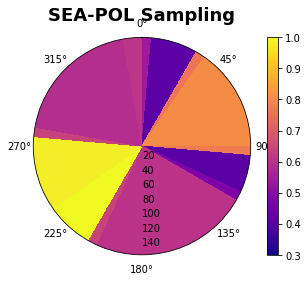

In [16]:
# Plot the SEA-POL coverage
radius = np.arange(0,151,50)
hoursTOT = np.sum(shipHeadingTime)
coverage2 = np.tile(coverage,(len(radius),1))

#polar plot
fig = plt.figure()
ax = fig.add_subplot(111,polar=True)
h1 = ax.pcolormesh(np.radians(azimuths),radius,coverage2/hoursTOT,cmap='plasma',vmin=0.3,vmax=1.0)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(180)
fig.colorbar(h1)
ax.set_title('SEA-POL Sampling',fontsize=18, weight='bold', loc='center')

plt.savefig('seapolsampling-percent.png')

In [13]:
#average august and september monthly precip
# = precipMonthlyMean.mean(dim="month")
precipAS = precipMonthlyMean.sel(month=slice(9,10))
precipASMean = precipAS.mean(dim="month")
precipASMean

<xarray.Dataset>
Dimensions:         (bnds: 2, latitude: 31, longitude: 51)
Coordinates:
  * longitude       (longitude) float32 300.0 301.0 302.0 ... 348.0 349.0 350.0
  * latitude        (latitude) float32 -10.0 -9.0 -8.0 -7.0 ... 18.0 19.0 20.0
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (longitude, bnds) float32 dask.array<chunksize=(51, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 dask.array<chunksize=(31, 2), meta=np.ndarray>
    precip          (latitude, longitude) float32 dask.array<chunksize=(31, 51), meta=np.ndarray>

In [14]:
latitudePirata

[-10, 0, 15, 0, 8, 0, 12, 4, 0, -6, 0, -8, -14, -19, 12, 4, -6, 21, 20]

Plot the ship track

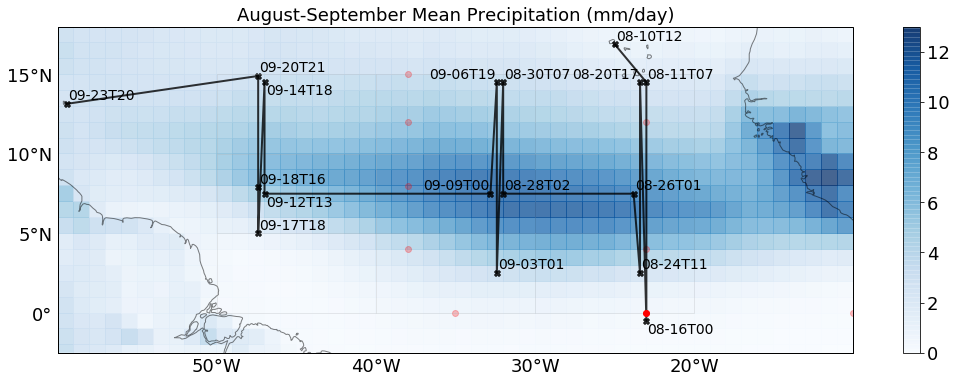

In [20]:
plt.figure(figsize = (18, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution = '50m',alpha=0.5)
#ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.25)
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=1,alpha = 0.25)
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlocator = mticker.FixedLocator([-50, -40, -30, -20])
gl.ylocator = mticker.FixedLocator([0, 5, 10, 15])
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}

#precipMonth = 9
#precipField = precipMonthlyMean
#plt.pcolormesh(precipField.sel(month=precipMonth).longitude.values-360.0, 
#               precipField.sel(month=precipMonth).latitude.values,
#               precipField.sel(month=precipMonth).precip.values,
#               vmin = 0.0, vmax = 12.0, cmap = 'Blues', alpha = 0.75,
#               shading='nearest'
#              )
plt.pcolormesh(precipASMean.longitude.values-360.0, 
               precipASMean.latitude.values,
               precipASMean.precip.values,
               vmin = 0.0, vmax = 13, cmap = 'Blues', alpha = 0.75,
               shading='nearest')

plt.title(f"August-September Mean Precipitation (mm/day)",fontSize=18)

ax.set_xlim(lonMin, lonMax)
ax.set_ylim(-2.5, 18)

cbar=plt.colorbar()
cbar.ax.tick_params(labelsize=18)

plt.scatter(shipLon,shipLat, alpha=0.8, color = 'k', marker = 'X')
p1 = plt.plot(shipLon,shipLat, alpha=0.8, color = 'k',linewidth= 2)

plt.scatter(longitudePirata[0:8], latitudePirata[0:8], color = 'r', label = 'PIRATA', alpha = 0.25)
plt.plot(longitudePirata[8], latitudePirata[8], color = 'r', label = 'PIRATA', alpha = 1.0,marker='o',markersize=6)
plt.scatter(longitudePirata[9:20], latitudePirata[9:20], color = 'r', label = 'PIRATA', alpha = 0.25)
#plt.plot(coordinates['bcoEast'], coordinates['bcoNorth'], marker = 'X',markersize=10)

texts = []
for x, y, s in zip(shipLon, shipLat, shipTrackTime):
    #texts.append(plt.text(x, y, str(s)[5:-3], color = 'k', fontsize = 14, backgroundcolor='white', bbox=dict(facecolor='white', alpha=0.6, linewidth=0, pad=1.0)))
    texts.append(plt.text(x, y, str(s)[5:-3], color = 'k', fontsize = 14))
adjust_text(texts, longitudePirata+list(shipLon), latitudePirata+list(shipLat), force_text = (1.5, 0.5))
sn.despine()

plt.savefig('Meteor_track.png')

## Distance to travel for HALO

In [16]:
coords_1 = (coordinates['bcoNorth'], coordinates['bcoEast'])
coords_2 = (coordinatesShip['turnCenterLat'], -45)
distanceKm = geopy.distance.geodesic(coords_1, coords_2).km
print(f'{int(distanceKm)}km')

1697km


In [17]:
coords_1 = (coordinates['mindeloNorth'], coordinates['mindeloEast'])
coords_2 = (coordinatesShip['turnCenterLat'], -30)
distanceKm = geopy.distance.geodesic(coords_1, coords_2).km
print(f'{int(distanceKm)}km')

1172km
